In [1]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.colors import TwoSlopeNorm
from tqdm.notebook import tqdm
from scFM_density_estimation.models import *

In [49]:
n = 2
N = 20_000
cond_dim = 4
batch_size = 512

locs = [[0, 0], [1, 1], [1, -1], [2, 2]]

C = np.random.randint(low=0, high=cond_dim, size=(N))
X = np.concatenate([np.random.normal(loc=locs[c], scale=1, size=(1, n)) for c in C])

alpha = 0.999
ema_loss = None
model = ConditionalFlowMatching(input_dim=n, hidden_dims=[1024, 1024, 1024], cond_dim=cond_dim,
                                use_encoder=False, use_ot_sampler=False).to("cuda")
optimizer = model.configure_optimizers()

X = torch.tensor(X).to("cuda").float()
C = F.one_hot(torch.tensor(C).long(), num_classes=cond_dim).to("cuda").float()

for k in tqdm(range(50000)):
    optimizer.zero_grad()

    indices = np.random.choice(range(X.shape[0]), size=batch_size, replace=False)
    loss = model.shared_step(X[indices], C[indices])
    
    loss.backward()
    optimizer.step()

    if ema_loss is None:
        ema_loss = loss.item()
    else:
        ema_loss = alpha * ema_loss + (1 - alpha) * loss.item() 

    if (k + 1) % 1000 == 0:
        print(f"Step {k+1}, EMA Loss: {ema_loss:.3f}")

  0%|          | 0/50000 [00:00<?, ?it/s]

Step 1000, EMA Loss: 2.318
Step 2000, EMA Loss: 1.856
Step 3000, EMA Loss: 1.687
Step 4000, EMA Loss: 1.623
Step 5000, EMA Loss: 1.598
Step 6000, EMA Loss: 1.589
Step 7000, EMA Loss: 1.583
Step 8000, EMA Loss: 1.581
Step 9000, EMA Loss: 1.581
Step 10000, EMA Loss: 1.579
Step 11000, EMA Loss: 1.578
Step 12000, EMA Loss: 1.578
Step 13000, EMA Loss: 1.579
Step 14000, EMA Loss: 1.576
Step 15000, EMA Loss: 1.575
Step 16000, EMA Loss: 1.574
Step 17000, EMA Loss: 1.573
Step 18000, EMA Loss: 1.573
Step 19000, EMA Loss: 1.573
Step 20000, EMA Loss: 1.573
Step 21000, EMA Loss: 1.571
Step 22000, EMA Loss: 1.572
Step 23000, EMA Loss: 1.572
Step 24000, EMA Loss: 1.573
Step 25000, EMA Loss: 1.571
Step 26000, EMA Loss: 1.572
Step 27000, EMA Loss: 1.571
Step 28000, EMA Loss: 1.572
Step 29000, EMA Loss: 1.570
Step 30000, EMA Loss: 1.572
Step 31000, EMA Loss: 1.573
Step 32000, EMA Loss: 1.570
Step 33000, EMA Loss: 1.573
Step 34000, EMA Loss: 1.572
Step 35000, EMA Loss: 1.571
Step 36000, EMA Loss: 1.572
S

In [50]:
C = np.random.randint(low=0, high=cond_dim, size=(N))
X = np.concatenate([np.random.normal(loc=locs[c], scale=1, size=(1, n)) for c in C])

data_samples = torch.tensor(X).to("cuda").float()
cond = F.one_hot(torch.tensor(C).long(), num_classes=cond_dim).to("cuda").float()

In [51]:
def div_fn_hutch_trace(u):
    def div_fn(x, eps):
        _, vjpfunc = torch.func.vjp(u, x)
        return (vjpfunc(eps)[0] * eps).sum()

    return div_fn

class NODEWrapper_with_trace_div(torch.nn.Module):
    def __init__(self, model, cond):
        super().__init__()
        self.model = model
        self.cond = cond
        self.div_fn, self.eps_fn = div_fn_hutch_trace, torch.randn_like

    def forward(self, t, x, *args, **kwargs):
        x = x[..., :-1]
        
        def vecfield(y):
            return self.model(y.unsqueeze(0), t, self.cond[:1]).squeeze()

        div = torch.vmap(self.div_fn(vecfield))(x, self.eps_fn(x))
        dx = self.model(x, t, self.cond)
        return torch.cat([dx, div[:, None]], dim=-1)

class NODEWrapper_with_trace_div_v2(torch.nn.Module):
    def __init__(self, model, cond_u, cond_v):
        super().__init__()
        self.model = model
        self.cond_u = cond_u
        self.cond_v = cond_v
        self.div_fn, self.eps_fn = div_fn_hutch_trace, torch.randn_like

    def forward(self, t, x, *args, **kwargs):
        x = x[..., :-3]
        
        def vecfield(y):
            return self.model(y.unsqueeze(0), t, self.cond_u[:1]).squeeze()
        
        div = torch.vmap(self.div_fn(vecfield))(x, self.eps_fn(x))
        ut = self.model(x, t, self.cond_u)
        vt = self.model(x, t, self.cond_v)
        # my score
        # score = (ut - t * x) / (1 - t + 1e-8)
        # the other score
        score = (t * ut - x) / (1 - t + 1e-8)
        correction_term = torch.linalg.vecdot(vt - ut, score)
        dlogp = -div + correction_term

        # print("time:", t)
        # print("score:", torch.linalg.vecdot(torch.ones_like(score), score))
        # print("correction term :", correction_term)
        
        return torch.cat([vt, dlogp[:, None], correction_term[:, None], torch.linalg.vecdot(torch.ones_like(score), score)[:, None]], dim=-1)

In [52]:
condition = np.array([0, 0, 0, 1])
mask = np.all(cond.cpu().numpy() == condition, axis=1)

log_p1_true = -0.5 * ((data_samples.cpu().numpy() - np.array(locs[np.argmax(condition)])) ** 2).sum(axis=1) - 0.5 * data_samples.shape[1] * np.log(2 * np.pi)

In [53]:
device = data_samples.device
node = NeuralODE(
    NODEWrapper_with_trace_div(model, torch.tensor(condition).float().expand(data_samples.shape[0], cond_dim).to(device)),
    solver="dopri5", sensitivity="adjoint", atol=1e-4, rtol=1e-4
)

with torch.no_grad():
    traj = node.trajectory(
        torch.cat([data_samples, torch.zeros(data_samples.shape[0], 1).to(device)], dim=-1),
        t_span=torch.linspace(1, 0, 100).to(device)
    )
z0, div = traj[-1][:, :-1], traj[-1][:, -1]
log_p1_hat = (-0.5 * (z0 ** 2).sum(dim=1) - 0.5 * z0.shape[1] * np.log(2 * np.pi) + div).cpu().numpy()

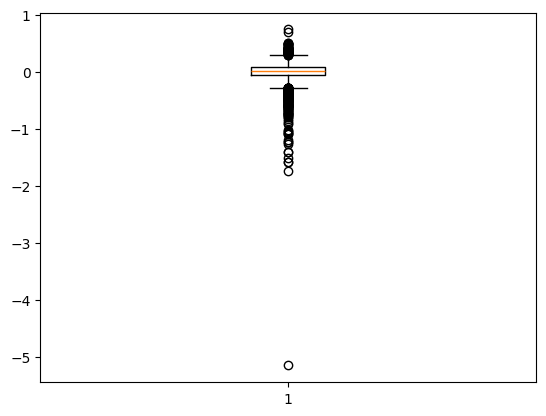

In [54]:
plt.boxplot((log_p1_hat - log_p1_true)[mask])
plt.show()

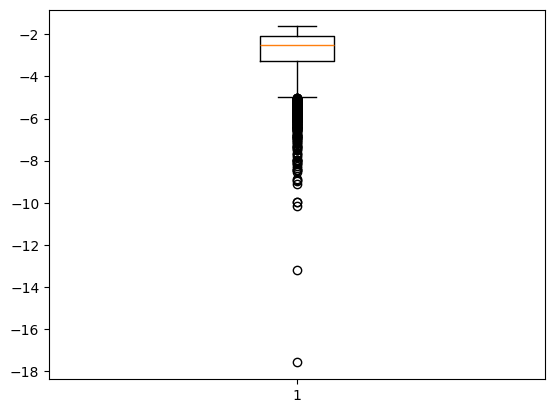

In [55]:
plt.boxplot(log_p1_hat[mask])
plt.show()

In [56]:
# plt.boxplot(div.cpu().numpy()[mask])
# plt.show()

min: -5.148590346384442
max: 2.8040815351069632


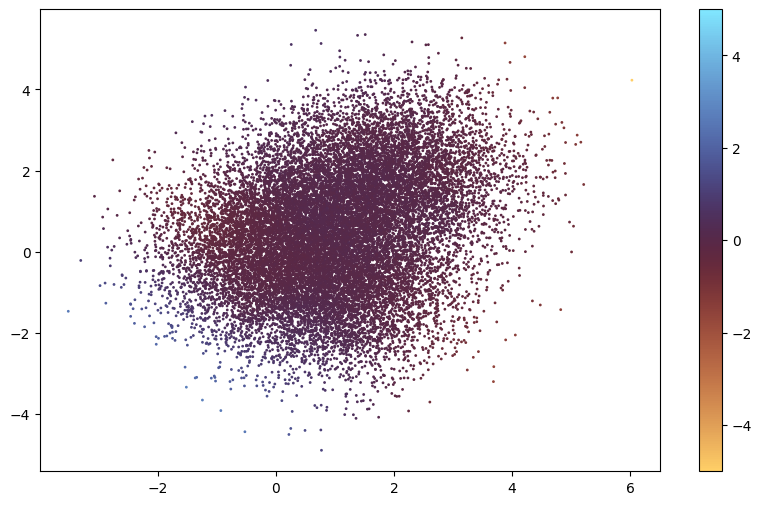

In [57]:
plot_x = data_samples.cpu().numpy()
plot_cond = cond.cpu().numpy()
color = log_p1_hat-log_p1_true

norm = TwoSlopeNorm(vmin=-5, vcenter=0, vmax=5)
print("min:", color.min())
print("max:", color.max())

fig, ax = plt.subplots()
fig.set_size_inches(10, 6)
cbar = ax.scatter(x=plot_x[:, 0], y=plot_x[:, 1], c=color, cmap="managua", norm=norm, s=1)
plt.colorbar(cbar, ax=ax)
plt.show()

min: -5.148590346384442
max: 0.7414469943045248


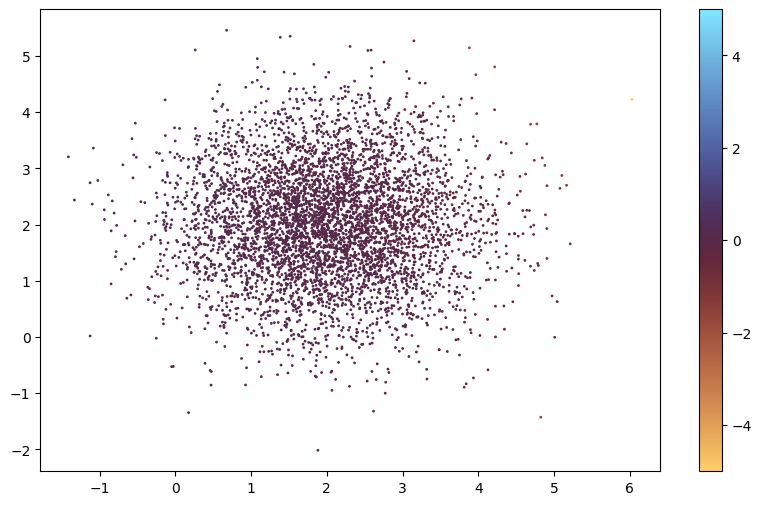

In [58]:
plot_x = data_samples.cpu().numpy()
plot_cond = cond.cpu().numpy()
color = log_p1_hat-log_p1_true

norm = TwoSlopeNorm(vmin=-5, vcenter=0, vmax=5)
print("min:", color[mask].min())
print("max:", color[mask].max())

fig, ax = plt.subplots()
fig.set_size_inches(10, 6)
cbar = ax.scatter(x=plot_x[:, 0][mask], y=plot_x[:, 1][mask], c=color[mask], cmap="managua", norm=norm, s=1)
plt.colorbar(cbar, ax=ax)
plt.show()

In [59]:
print(condition)

[0 0 0 1]


In [60]:
device = data_samples.device
node = NeuralODE(
    NODEWrapper_with_trace_div_v2(model, torch.tensor(condition).float().expand(data_samples.shape[0], cond_dim).to(device),
                                  torch.tensor([1, 0, 0, 0]).float().expand(data_samples.shape[0], cond_dim).to(device)),
    solver="dopri5", sensitivity="adjoint", atol=1e-4, rtol=1e-4
)

with torch.no_grad():
    traj = node.trajectory(
        torch.cat([data_samples, torch.zeros(data_samples.shape[0], 3).to(device)], dim=-1),
        t_span=torch.linspace(1, 0, 100).to(device)
    )
z0, dlogp, correction_term, score = traj[-1][:, :-3], traj[-1][:, -3], traj[-1][:, -2], traj[-1][:, -1]
log_p1_hat_v2 = (-0.5 * (z0 ** 2).sum(dim=1) - 0.5 * z0.shape[1] * np.log(2 * np.pi) - dlogp).cpu().numpy()

In [61]:
# plt.boxplot((log_p1_hat - log_p1_hat_v2)[mask])
# plt.show()

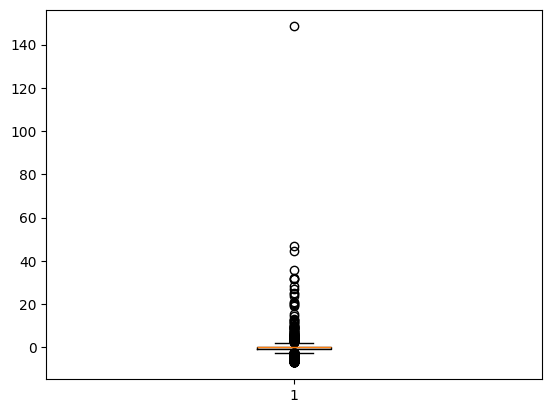

In [62]:
plt.boxplot((log_p1_hat_v2 - log_p1_true)[mask])
plt.show()

In [63]:
# plt.boxplot(log_p1_hat_v2[mask])
# plt.show()

In [64]:
# plt.boxplot(score.cpu().numpy()[mask])
# plt.show()

In [65]:
# plt.boxplot(correction_term.cpu().numpy()[mask])
# plt.show()

In [66]:
# plt.boxplot((dlogp - correction_term).cpu().numpy()[mask])
# plt.show()

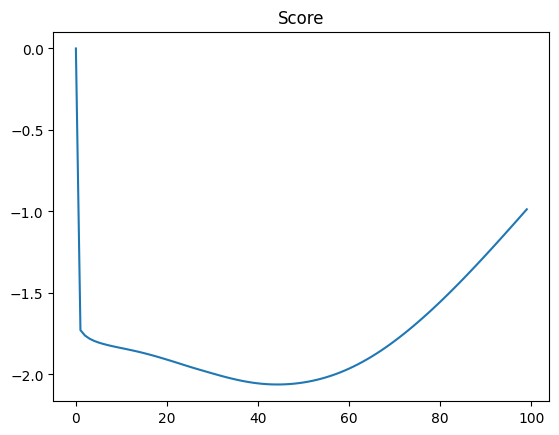

In [67]:
plt.plot(traj[:, 0, -1].cpu().numpy())
plt.title("Score")
plt.show()

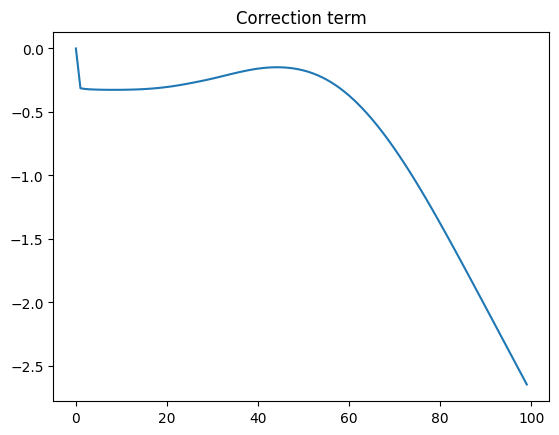

In [68]:
plt.plot(traj[:, 0, -2].cpu().numpy())
plt.title("Correction term")
plt.show()

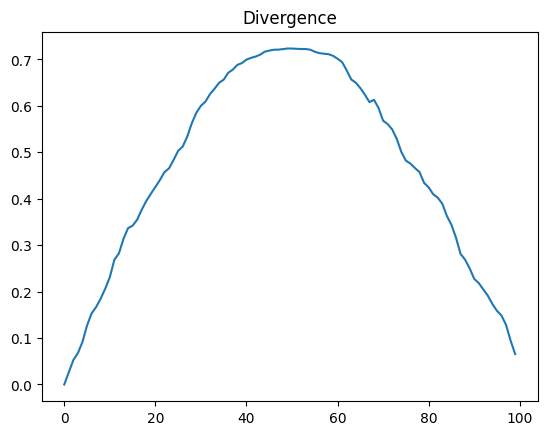

In [69]:
plt.plot((traj[:, 0, -3] - traj[:, 0, -2]).cpu().numpy())
plt.title("Divergence")
plt.show()

min: -113.50219552836647
max: 148.41633198637922


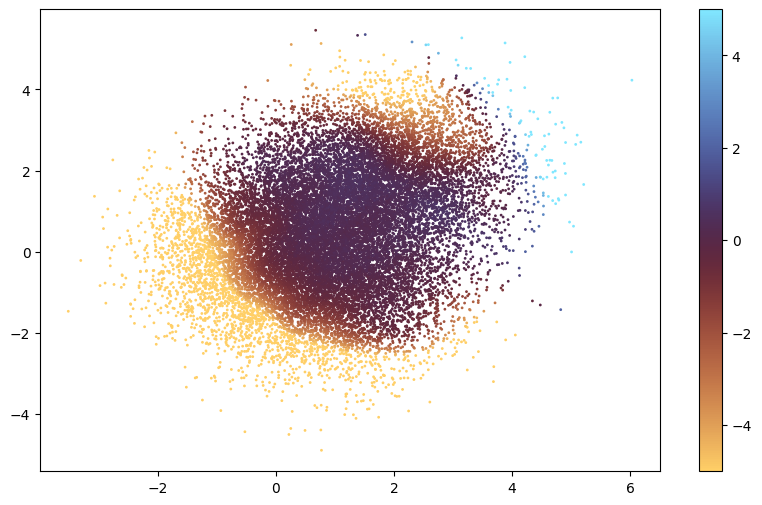

In [70]:
plot_x = data_samples.cpu().numpy()
plot_cond = cond.cpu().numpy()
color = log_p1_hat_v2-log_p1_true

norm = TwoSlopeNorm(vmin=-5, vcenter=0, vmax=5)
print("min:", color.min())
print("max:", color.max())

fig, ax = plt.subplots()
fig.set_size_inches(10, 6)
cbar = ax.scatter(x=plot_x[:, 0], y=plot_x[:, 1], c=color, cmap="managua", norm=norm, s=1)
plt.colorbar(cbar, ax=ax)
plt.show()

min: -6.973202905154085
max: 148.41633198637922


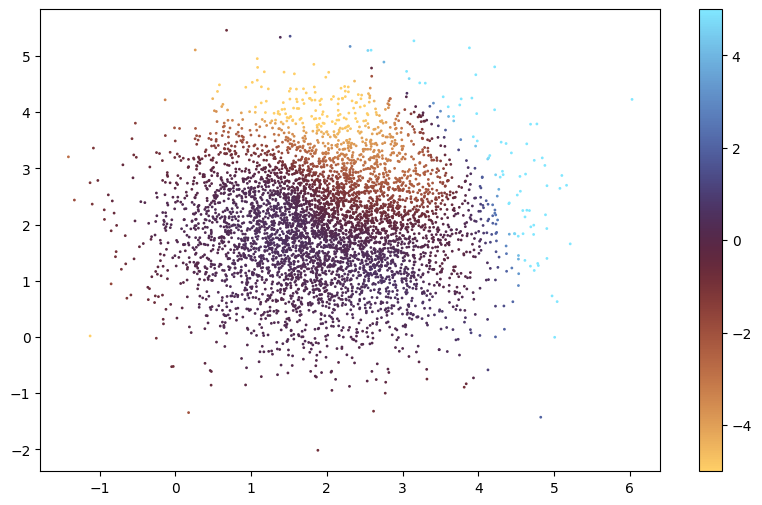

In [71]:
plot_x = data_samples.cpu().numpy()
plot_cond = cond.cpu().numpy()
color = log_p1_hat_v2-log_p1_true

norm = TwoSlopeNorm(vmin=-5, vcenter=0, vmax=5)
print("min:", color[mask].min())
print("max:", color[mask].max())

fig, ax = plt.subplots()
fig.set_size_inches(10, 6)
cbar = ax.scatter(x=plot_x[:, 0][mask], y=plot_x[:, 1][mask], c=color[mask], cmap="managua", norm=norm, s=1)
plt.colorbar(cbar, ax=ax)
plt.show()

min: -152.91261905479428
max: 19.86164032517983


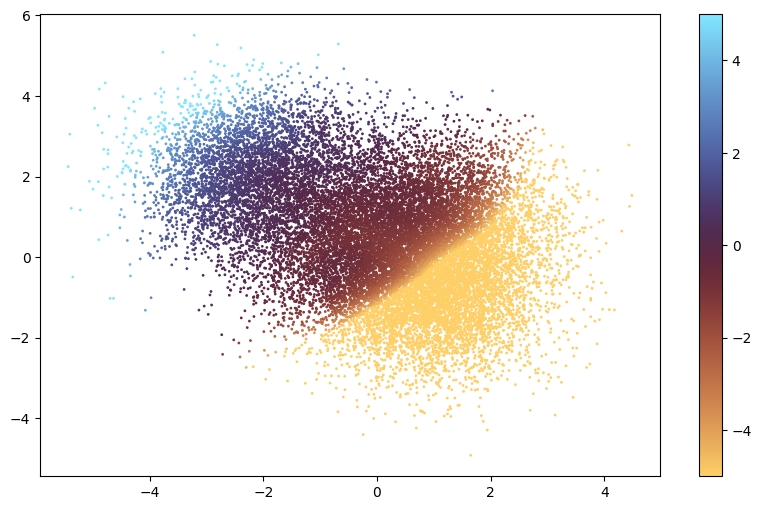

In [48]:
plot_x = data_samples.cpu().numpy()
plot_cond = cond.cpu().numpy()
color = log_p1_hat_v2-log_p1_true

norm = TwoSlopeNorm(vmin=-5, vcenter=0, vmax=5)
print("min:", color.min())
print("max:", color.max())

fig, ax = plt.subplots()
fig.set_size_inches(10, 6)
cbar = ax.scatter(x=plot_x[:, 0], y=plot_x[:, 1], c=color, cmap="managua", norm=norm, s=1)
plt.colorbar(cbar, ax=ax)
plt.show()